# Inventory Surprises, Supply Shocks, and the Price of Crude Oil

Basic economics says price responds to supply. Holding demand fixed, more supply should push price down, and less should push it up.

This notebook tests that idea two ways. First, using the weekly U.S. inventory report, the single most closely watched recurring data release in the oil market. Second, using six landmark OPEC and OPEC+ production decisions.

The central finding: a naive test using the raw weekly inventory change finds nothing. Once the raw change is split into an expected seasonal component and a surprise component, the surprise component reveals a clean, statistically significant relationship. That gap between the naive and the properly specified test is the main result.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from inventory_elasticity import (
    load_inventory_data, load_wti, build_seasonal_surprise,
    attach_price_reaction, naive_regression, surprise_regression, START,
)
from opec_event_study import build_event_table, OPEC_EVENTS

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Data

U.S. commercial crude oil inventories, excluding the Strategic Petroleum Reserve, downloaded directly from the EIA's public historical file. No API key required.

In [2]:
inv_full = load_inventory_data()
wti = load_wti()

print(f"Inventory data: {len(inv_full):,} weekly observations, "
      f"{inv_full.week_ending.min():%Y-%m-%d} to {inv_full.week_ending.max():%Y-%m-%d}")
print(f"WTI price data: {len(wti):,} trading days")
inv_full.tail()

Inventory data: 2,286 weekly observations, 1982-08-20 to 2026-07-17
WTI price data: 5,422 trading days


,week_ending,stocks_kbbl
2281,2026-06-19,412134
2282,2026-06-26,408359
2283,2026-07-03,411357
2284,2026-07-10,409665
2285,2026-07-17,411675


## 2. The naive test

Regress the WTI return around each week's report directly on the raw reported change in inventories.

In [3]:
inv = build_seasonal_surprise(inv_full, window_years=5)
inv = inv[inv.week_ending >= START].reset_index(drop=True)
inv = attach_price_reaction(inv, wti)

naive_fit, naive_d = naive_regression(inv)
print(naive_fit.summary())

                            OLS Regression Results                            
Dep. Variable:             return_pct   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.524
Date:                Fri, 24 Jul 2026   Prob (F-statistic):              0.112
Time:                        22:58:11   Log-Likelihood:                -2148.6
No. Observations:                 864   AIC:                             4301.
Df Residuals:                     862   BIC:                             4311.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0523      0.099      0.528   

The coefficient is negative, the right direction, but not statistically significant (p = 0.112). Read literally, this says the market does not respond to the inventory report at all — which contradicts both theory and how closely traders are known to watch this release.

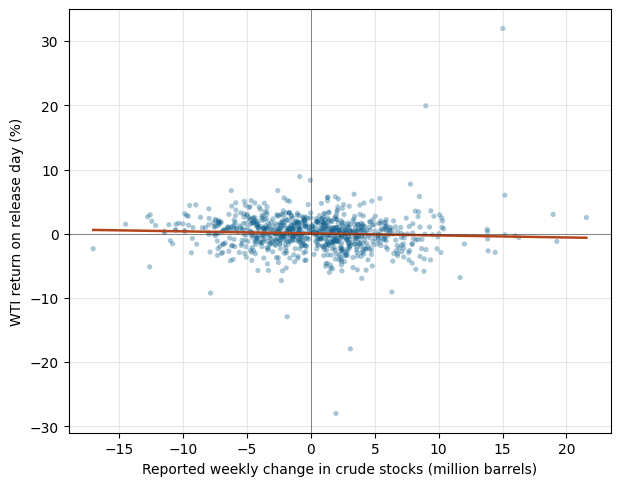

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(naive_d.change_mmbbl, naive_d.return_pct, s=14, color="#0b5d8a", alpha=0.35, edgecolors="none")
xs = np.linspace(naive_d.change_mmbbl.min(), naive_d.change_mmbbl.max(), 100)
ys = naive_fit.params["const"] + naive_fit.params["change_mmbbl"] * xs
ax.plot(xs, ys, color="#b5451c", lw=1.8)
ax.axhline(0, color="#1a1a1a", lw=0.7, alpha=0.5)
ax.axvline(0, color="#1a1a1a", lw=0.7, alpha=0.5)
ax.set_xlabel("Reported weekly change in crude stocks (million barrels)")
ax.set_ylabel("WTI return on release day (%)")
ax.grid(alpha=0.3)
plt.show()

## 3. Why the naive test fails: seasonal patterns are not surprises

Crude oil inventories follow well-known seasonal patterns — refinery maintenance season, summer driving season. Markets already know these patterns, so a lot of the raw weekly change is not news. The EIA's own public reporting reflects this: it routinely describes current inventories relative to the "five-year average" for that time of year, rather than describing the raw week-over-week change in isolation.

Following that same convention, this notebook builds a surprise measure: the reported change minus the average change reported in the same calendar week over the trailing five years.

In [5]:
surprise_fit, surprise_d = surprise_regression(inv)
print(surprise_fit.summary())

                            OLS Regression Results                            
Dep. Variable:             return_pct   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     7.925
Date:                Fri, 24 Jul 2026   Prob (F-statistic):            0.00499
Time:                        22:58:11   Log-Likelihood:                -2137.7
No. Observations:                 861   AIC:                             4279.
Df Residuals:                     859   BIC:                             4289.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0503      0.099      0.

Now the coefficient is negative **and** statistically significant (p = 0.005). The correlation with price nearly doubles, from -0.054 (raw) to -0.096 (surprise). A larger-than-usual build predicts a lower price; a larger-than-usual draw predicts a higher price — exactly what supply and demand theory says should happen.

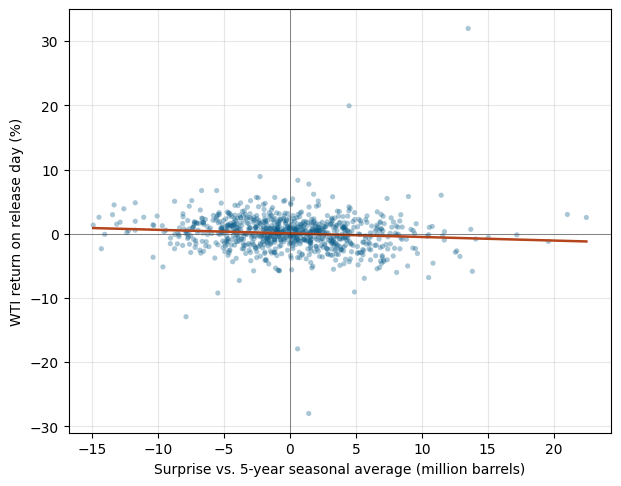

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(surprise_d.surprise_mmbbl, surprise_d.return_pct, s=14, color="#0b5d8a", alpha=0.35, edgecolors="none")
xs = np.linspace(surprise_d.surprise_mmbbl.min(), surprise_d.surprise_mmbbl.max(), 100)
ys = surprise_fit.params["const"] + surprise_fit.params["surprise_mmbbl"] * xs
ax.plot(xs, ys, color="#b5451c", lw=1.8)
ax.axhline(0, color="#1a1a1a", lw=0.7, alpha=0.5)
ax.axvline(0, color="#1a1a1a", lw=0.7, alpha=0.5)
ax.set_xlabel("Surprise vs. 5-year seasonal average (million barrels)")
ax.set_ylabel("WTI return on release day (%)")
ax.grid(alpha=0.3)
plt.show()

## 4. Which direction does the relationship run?

The regression above is contemporaneous — it tests whether the surprise and the return move together in the same week, not which one moves first. A Granger causality test checks whether past values of one variable improve a prediction of the other, beyond that variable's own past. It's a test of predictive content, not causation in the everyday sense.

In [7]:
from inventory_elasticity import granger_causality

granger = granger_causality(inv)
granger

,direction,lag_weeks,f_stat,p_value
0,surprise -> return,1,6.8873,0.0088
1,surprise -> return,2,3.5599,0.0289
2,surprise -> return,3,2.3350,0.0725
3,surprise -> return,4,1.8550,0.1164
4,return -> surprise,1,2.6038,0.1070
5,return -> surprise,2,0.8311,0.4359
6,return -> surprise,3,1.2695,0.2836
7,return -> surprise,4,1.3415,0.2527


Past surprises predict future returns at one week (p = 0.009) and two weeks (p = 0.029), fading by three and four weeks. Past returns do **not** predict future surprises at any tested lag (p > 0.10 throughout).

The relationship runs one direction: surprise to price, not the reverse. This rules out one alternative story for the earlier result — that the market was simply anticipating the number in advance, with returns leading the announcement rather than following it. The one- to two-week decay also shows the market doesn't fully absorb a surprise in a single trading day.

## 4. Robustness

### Is the relationship stable over time?

In [8]:
from robustness import subsample_check, window_sensitivity_check

sub = subsample_check(inv_full, wti)
sub

,period,n,coefficient,p_value,corr
0,2010-2019,520,-0.1247,0.0000,-0.2401
1,2020-2026,341,0.0017,0.9614,0.0026


A striking break. The relationship is more than twice as strong pre-2020 as in the full sample, and highly significant. After 2020 it is statistically and economically zero. This mirrors a pattern found independently in the companion options project — several market relationships that held reliably before 2020 weakened or vanished afterward, plausibly because the 2020-2026 window packs in an unusually wide range of regimes (COVID demand collapse, negative prices, the Ukraine invasion, a tightening and loosening cycle) in a short span.

### Does the 5-year seasonal window choice matter?

In [9]:
win = window_sensitivity_check(inv_full, wti)
win

,seasonal_window_years,n,coefficient,p_value,corr
0,3,393,-0.0611,0.0658,-0.0929
1,5,861,-0.0557,0.0050,-0.0956
2,7,861,-0.0497,0.0162,-0.0819


The coefficient stays negative and similar in size (-0.05 to -0.06) across 3, 5, and 7-year windows. The 3-year window has a smaller usable sample, since it still needs 3 years of prior history to compute a seasonal average, which costs it some statistical power — its p-value of 0.066 just misses the conventional 5% threshold despite a similar point estimate.

## 5. A different kind of supply shock: OPEC decisions

Inventories are a continuous, weekly signal. OPEC decisions are discrete, deliberate interventions — producers explicitly agreeing to produce more or less, with the stated goal of moving price.

OPEC does not meet on a fixed schedule the way the Federal Reserve does, and there is no single free, complete historical calendar of every meeting. Rather than compile a long list at risk of error, this notebook examines six decisions that are unambiguous, independently documented turning points, each checked against multiple news sources.

In [10]:
table = build_event_table(wti)
table

,date,description,expected_direction,return_on_day,return_t_plus_1,cumulative_t0_t1
0,2014-11-27,OPEC declines to cut output despite falling pr...,bearish,-10.7942,4.2182,-6.5761
1,2016-12-10,Declaration of Cooperation: first OPEC+ deal,bullish,2.5497,0.2835,2.8333
2,2020-03-06,OPEC+ talks collapse; Saudi-Russia price war b...,bearish,-10.6087,-28.2206,-38.8293
3,2020-04-12,OPEC+ agrees record 9.7 million bpd cut,bullish,-1.5497,-10.8290,-12.3787
4,2022-10-05,OPEC+ agrees 2 million bpd cut,bullish,1.4230,0.7832,2.2062
5,2023-04-02,Surprise additional voluntary cuts of 1.16 mil...,bullish,6.0881,0.3600,6.4481


Five of six moved in the theoretically expected direction. The one exception — the April 12, 2020 record 9.7 million bpd cut — is explainable rather than a contradiction: that agreement landed in the middle of the COVID-19 demand collapse, and the market judged that even a record supply cut couldn't offset the collapse on the demand side. Price responds to the *net* of supply and demand shocks, not to a supply announcement in isolation.

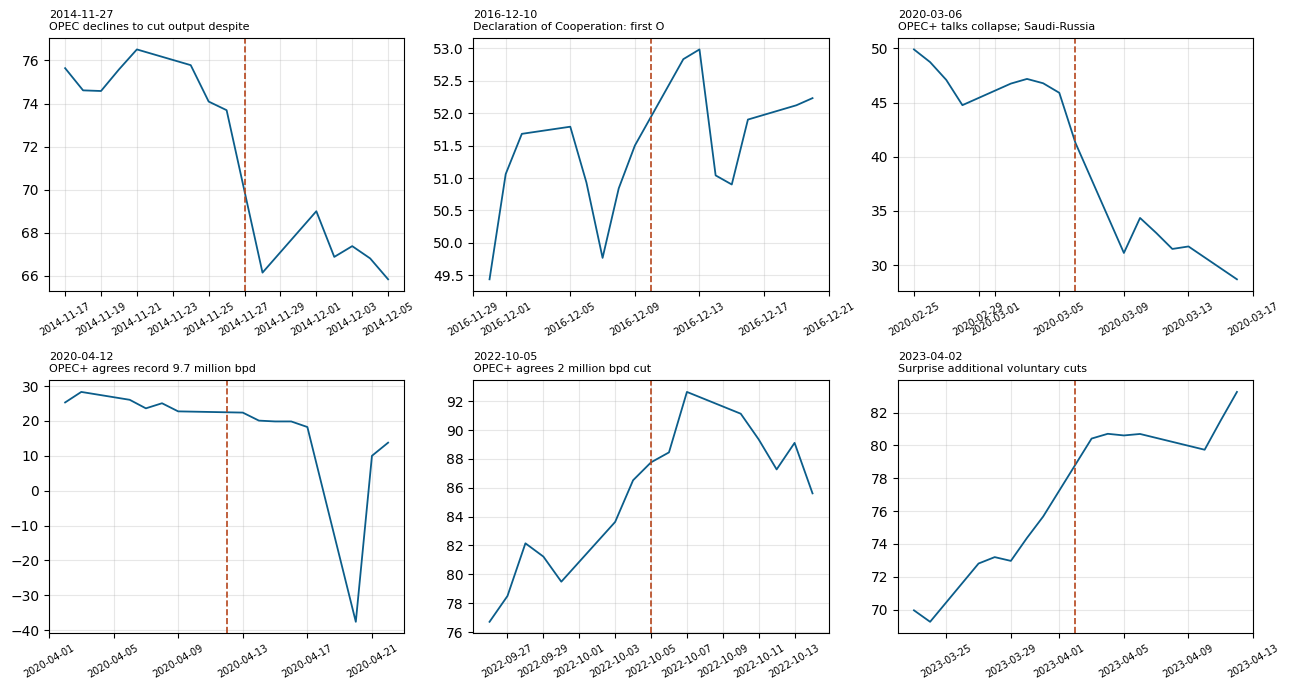

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for ax, (_, row) in zip(axes, table.iterrows()):
    ts = pd.Timestamp(row["date"])
    window = wti.loc[ts - pd.Timedelta(days=10): ts + pd.Timedelta(days=10)]
    ax.plot(window.index, window.values, color="#0b5d8a", lw=1.3)
    ax.axvline(ts, color="#b5451c", ls="--", lw=1.2)
    ax.set_title(f"{row['date']}\n{row['description'][:35]}", fontsize=8, loc="left")
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Limitations

- **The release date is approximated**, not matched to a hand-verified historical EIA schedule, since no free complete file of holiday-adjusted release dates exists across the full sample. This adds timing noise in roughly 6-8 weeks a year, which should weaken rather than manufacture the estimated relationship.
- **The seasonal-surprise measure is a free substitute for actual market consensus.** The academic literature (Miao et al., 2018) uses proprietary Bloomberg survey data for a true "expected" figure; this notebook's seasonal average is transparent and reproducible but not identical to it.
- **Six OPEC events is a small, illustrative sample**, not large enough for the kind of formal hypothesis testing the companion project's 132-meeting FOMC study supports.
- **Front-month futures carry roll effects**, not adjusted for here, consistent with the companion project.